## 🧩 Inspiração na Implementação 1D do P-Model

A implementação original do modelo Pmodel em uma dimensão (1D), desenvolvida por **R.R. Rosa, R. Sautter e N. Joshi**, serviu como **inspiração principal** para a extensão do modelo ao domínio bidimensional (2D) com evolução temporal.

Essa versão 1D, adaptada dos trabalhos de **Meneveau & Sreenivasan (1987)**, utiliza um processo de multiplicação estocástica controlado por um parâmetro `p`, responsável por introduzir **intermitência estatística** e **auto-similaridade** em estruturas multifractais. O modelo segue a abordagem original de dividir iterativamente os valores de uma sequência, aplicando flutuações assimétricas, com comportamento guiado pela teoria de **Didier Sornette**.

A lógica central do modelo, baseada na função `next_step_1d`, foi reutilizada e adaptada na implementação 2D para que cada pixel da matriz evolua no tempo como uma série Pmodel, com acoplamento espacial implementado via suavização gaussiana. A função `fractal_spectrum_1d`, embora opcional, também sugere a possibilidade de ajustar o espectro de frequências para simular distribuições com determinadas inclinações espectrais — um recurso que pode ser estendido futuramente para o caso 2D.

Portanto, o modelo 1D serviu como base conceitual e técnica para o desenvolvimento do **modelo Pmodel 2D com evolução temporal**, permitindo gerar campos espaciais sintéticos com características multifractais e dinâmica controlada no tempo.

### 🔗 Referências Técnicas Utilizadas

- Meneveau, C., & Sreenivasan, K. R. (1987). Simple multifractal cascade model for fully developed turbulence. *Physical Review Letters*, 59(13), 1424.


In [269]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import io
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib as mpl
plt.rcParams["figure.dpi"] = 300
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

%matplotlib inline

#XP-model adapted from Meneveau & Sreenevasan, 1987 & Malara et al., 2016
#Valid Ranges for p, based on Didier-Sornette's Theory
#Author: R.R.Rosa, R. Sautter and  N. Joshi
#Version: 1.1
#Date: 23/08/2022

import numpy as np
#import statistics as stat
from matplotlib import pyplot


def pmodel(noValues=1024, p=0.5, slope=[]):
    noOrders = int(np.ceil(np.log2(noValues)))
    noValuesGenerated = 2**noOrders

    dx = np.array([1])
    for n in range(noOrders):
        dx = next_step_1d(dx, p)

    if (slope):
        fourierCoeff = fractal_spectrum_1d(noValues, slope/2)
        meanVal = np.mean(dx)
        stdy = np.std(dx)
        x = np.fft.ifft(dx - meanVal)
        phase = np.angle(x)
        x = fourierCoeff*np.exp(1j*phase)
        x = np.fft.fft(x).real
        x *= stdy/np.std(x)
        x += meanVal
    else:
        x = dx

    return x[0:noValues], dx[0:noValues]


def next_step_1d(dx, p):
    y2 = np.zeros(dx.size*2)
    sign = np.random.rand(1, dx.size) - 0.5
    sign /= np.abs(sign)
    y2[0:2*dx.size:2] = dx + sign*(1-2*p)*dx
    y2[1:2*dx.size+1:2] = dx - sign*(1-2*p)*dx

    return y2


def fractal_spectrum_1d(noValues, slope):
    ori_vector_size = noValues
    ori_half_size = ori_vector_size//2
    a = np.zeros(ori_vector_size)

    for t2 in range(ori_half_size):
        index = t2
        t4 = 1 + ori_vector_size - t2
        if (t4 >= ori_vector_size):
            t4 = t2
        coeff = (index + 1)**slope
        a[t2] = coeff
        a[t4] = coeff

    a[1] = 0

    return a

In [270]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

In [271]:
import numpy as np

N = 1024
p_values = np.linspace(0.1, 0.49, 100)

time_series_pmodel = []

lower_limit = np.percentile(p_values, 20)
upper_limit = np.percentile(p_values, 90)

for p in p_values:
    np.random.seed(126)
    
    y, dy = pmodel(N, p, 2)
    
    inside = lower_limit <= p <= upper_limit
    
    time_series_pmodel.append((p, dy, inside))

In [272]:
def normalize(x):
    x = x + 0.01
    return x / (np.max(x) + 1e-8)

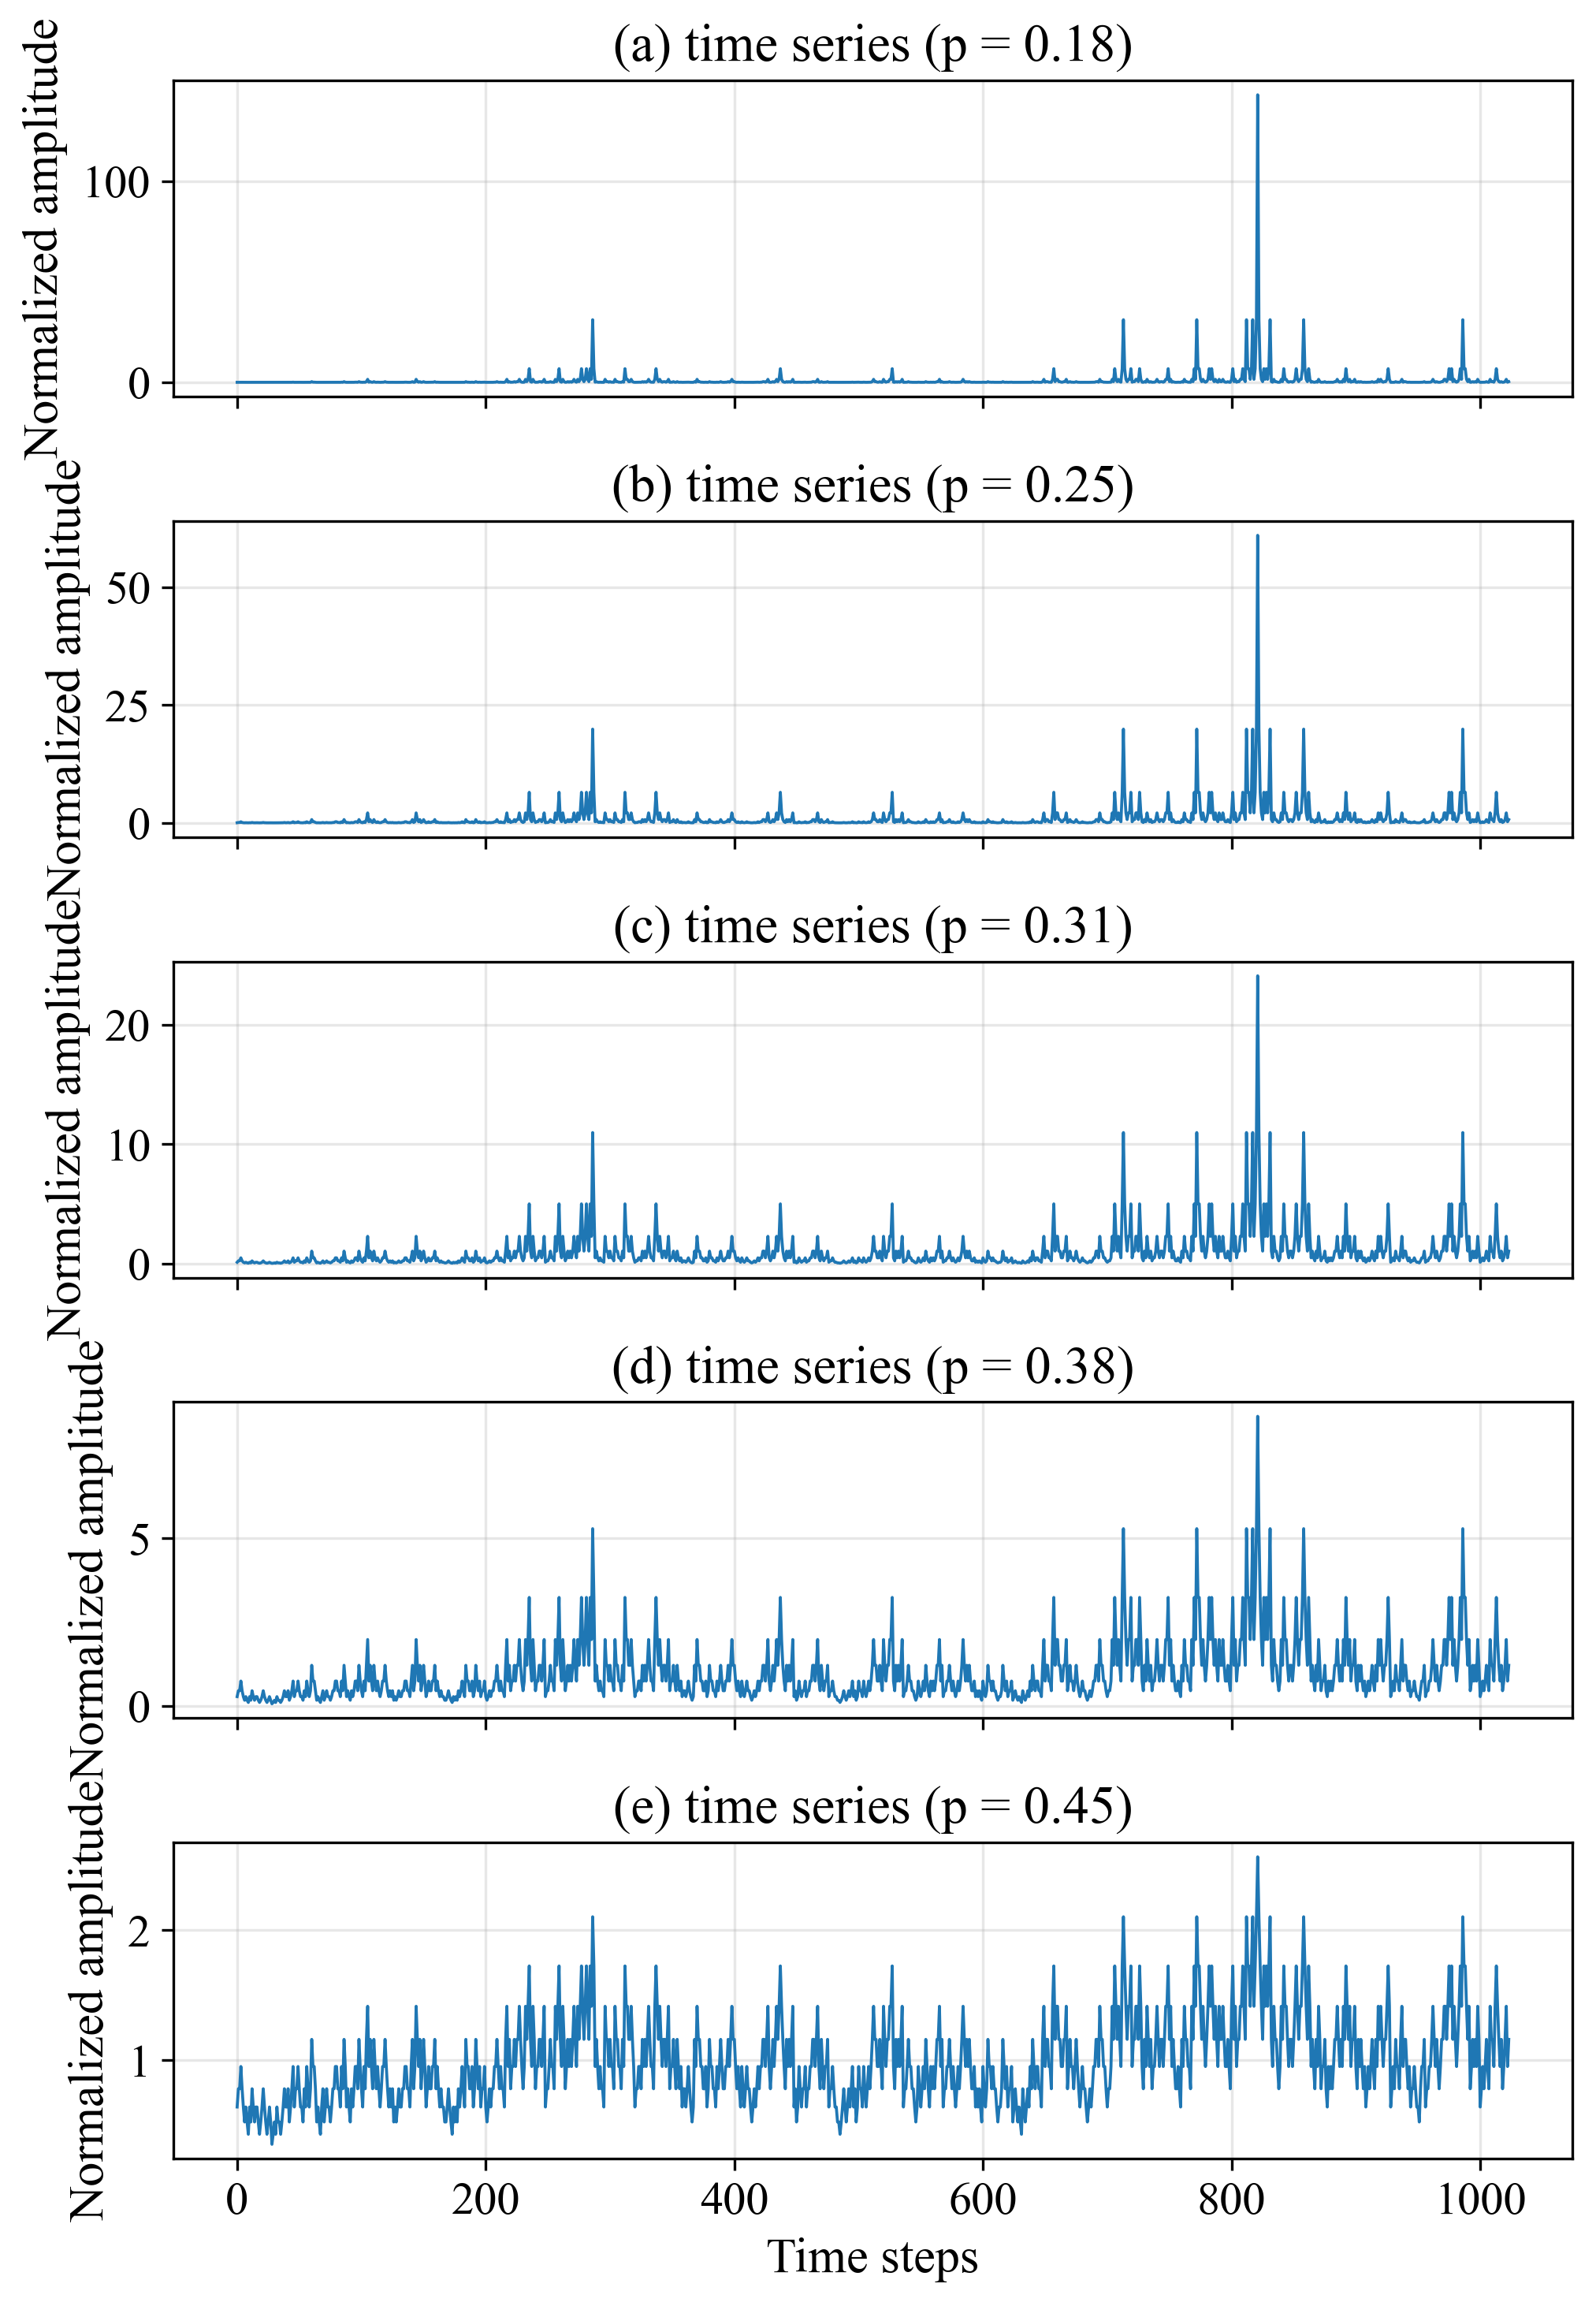

In [273]:
n_series = 5

filtered_series = [(p, serie) for (p, serie, inside) in time_series_pmodel if inside]


indices = np.linspace(0, len(filtered_series) - 1, n_series, dtype=int)
selected_series = [filtered_series[i] for i in indices]

fig, axes = plt.subplots(n_series, 1, figsize=(7, 2*n_series), sharex=True)

if n_series == 1:
    axes = [axes]

for i, (p_val, serie) in enumerate(selected_series):
    axes[i].plot(serie, lw=0.9)
    axes[i].set_ylabel("Normalized amplitude")
    axes[i].set_title(f"({chr(97+i)}) time series (p = {p_val:.2f})")
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel("Time steps")

plt.tight_layout()
plt.show()


In [274]:
import numpy as np
from scipy.optimize import curve_fit

def cumulative_energy_fit(series, return_both=False):

    series = series - np.mean(series)

    fft_vals = np.fft.rfft(series)
    psd = np.abs(fft_vals)**2
    freqs = np.fft.rfftfreq(len(series))

    cumulative_energy = np.cumsum(psd)
    cumulative_energy /= cumulative_energy[-1]

    mask = freqs > 0
    x = freqs[mask]
    y = cumulative_energy[mask]

    # ---------- LOG MODEL ----------
    def log_model(x, a, b):
        return a * np.log(x) + b

    params_log, _ = curve_fit(log_model, x, y)
    y_log = log_model(x, *params_log)

    ss_res_log = np.sum((y - y_log)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_log = 1 - ss_res_log / ss_tot

    # ---------- EXPONENTIAL MODEL ----------
    def exp_model(x, b):
        return 1 - np.exp(-b * x)

    params_exp, _ = curve_fit(
        exp_model, x, y,
        bounds=(0, np.inf),   # força b > 0
        maxfev=10000
    )

    y_exp = exp_model(x, *params_exp)

    ss_res_exp = np.sum((y - y_exp)**2)
    r2_exp = 1 - ss_res_exp / ss_tot

    print(f"R² Log: {r2_log:.4f}, R² Exp: {r2_exp:.4f}")

    # ---------- Se quiser os dois ----------
    if return_both:
        x_fit = np.linspace(min(x), max(x), 500)

        return {
            "x": x,
            "y": y,
            "log": {
                "params": params_log,
                "r2": r2_log,
                "y_fit": log_model(x_fit, *params_log)
            },
            "exp": {
                "params": params_exp,
                "r2": r2_exp,
                "y_fit": exp_model(x_fit, *params_exp)
            },
            "x_fit": x_fit
        }

    # ---------- Caso padrão: retorna só o melhor ----------
    if r2_log > r2_exp:
        best_model = "Log"
        y_best = log_model
        params_best = params_log
        r2_best = r2_log
    else:
        best_model = "Exp saturating"
        y_best = exp_model
        params_best = params_exp
        r2_best = r2_exp

    x_fit = np.linspace(min(x), max(x), 500)
    y_fit = y_best(x_fit, *params_best)

    print(f"Melhor modelo: {best_model}")
    print(f"R² = {r2_best:.4f}")

    return x, y, x_fit, y_fit, best_model, r2_best

In [ ]:
plt.rcParams.update({
    "font.size": 15,       
    "axes.titlesize": 16,  
    "axes.labelsize": 15,  
    "xtick.labelsize": 14, 
    "ytick.labelsize": 14, 
    "legend.fontsize": 12  
})

R² Log: 0.8892, R² Exp: 0.9821
Melhor modelo: Exp saturating
R² = 0.9821
R² Log: 0.9257, R² Exp: 0.9619
Melhor modelo: Exp saturating
R² = 0.9619
R² Log: 0.9563, R² Exp: 0.8821
R² Log: 0.9765, R² Exp: 0.7501
Melhor modelo: Log
R² = 0.9765
R² Log: 0.9873, R² Exp: 0.6165
Melhor modelo: Log
R² = 0.9873


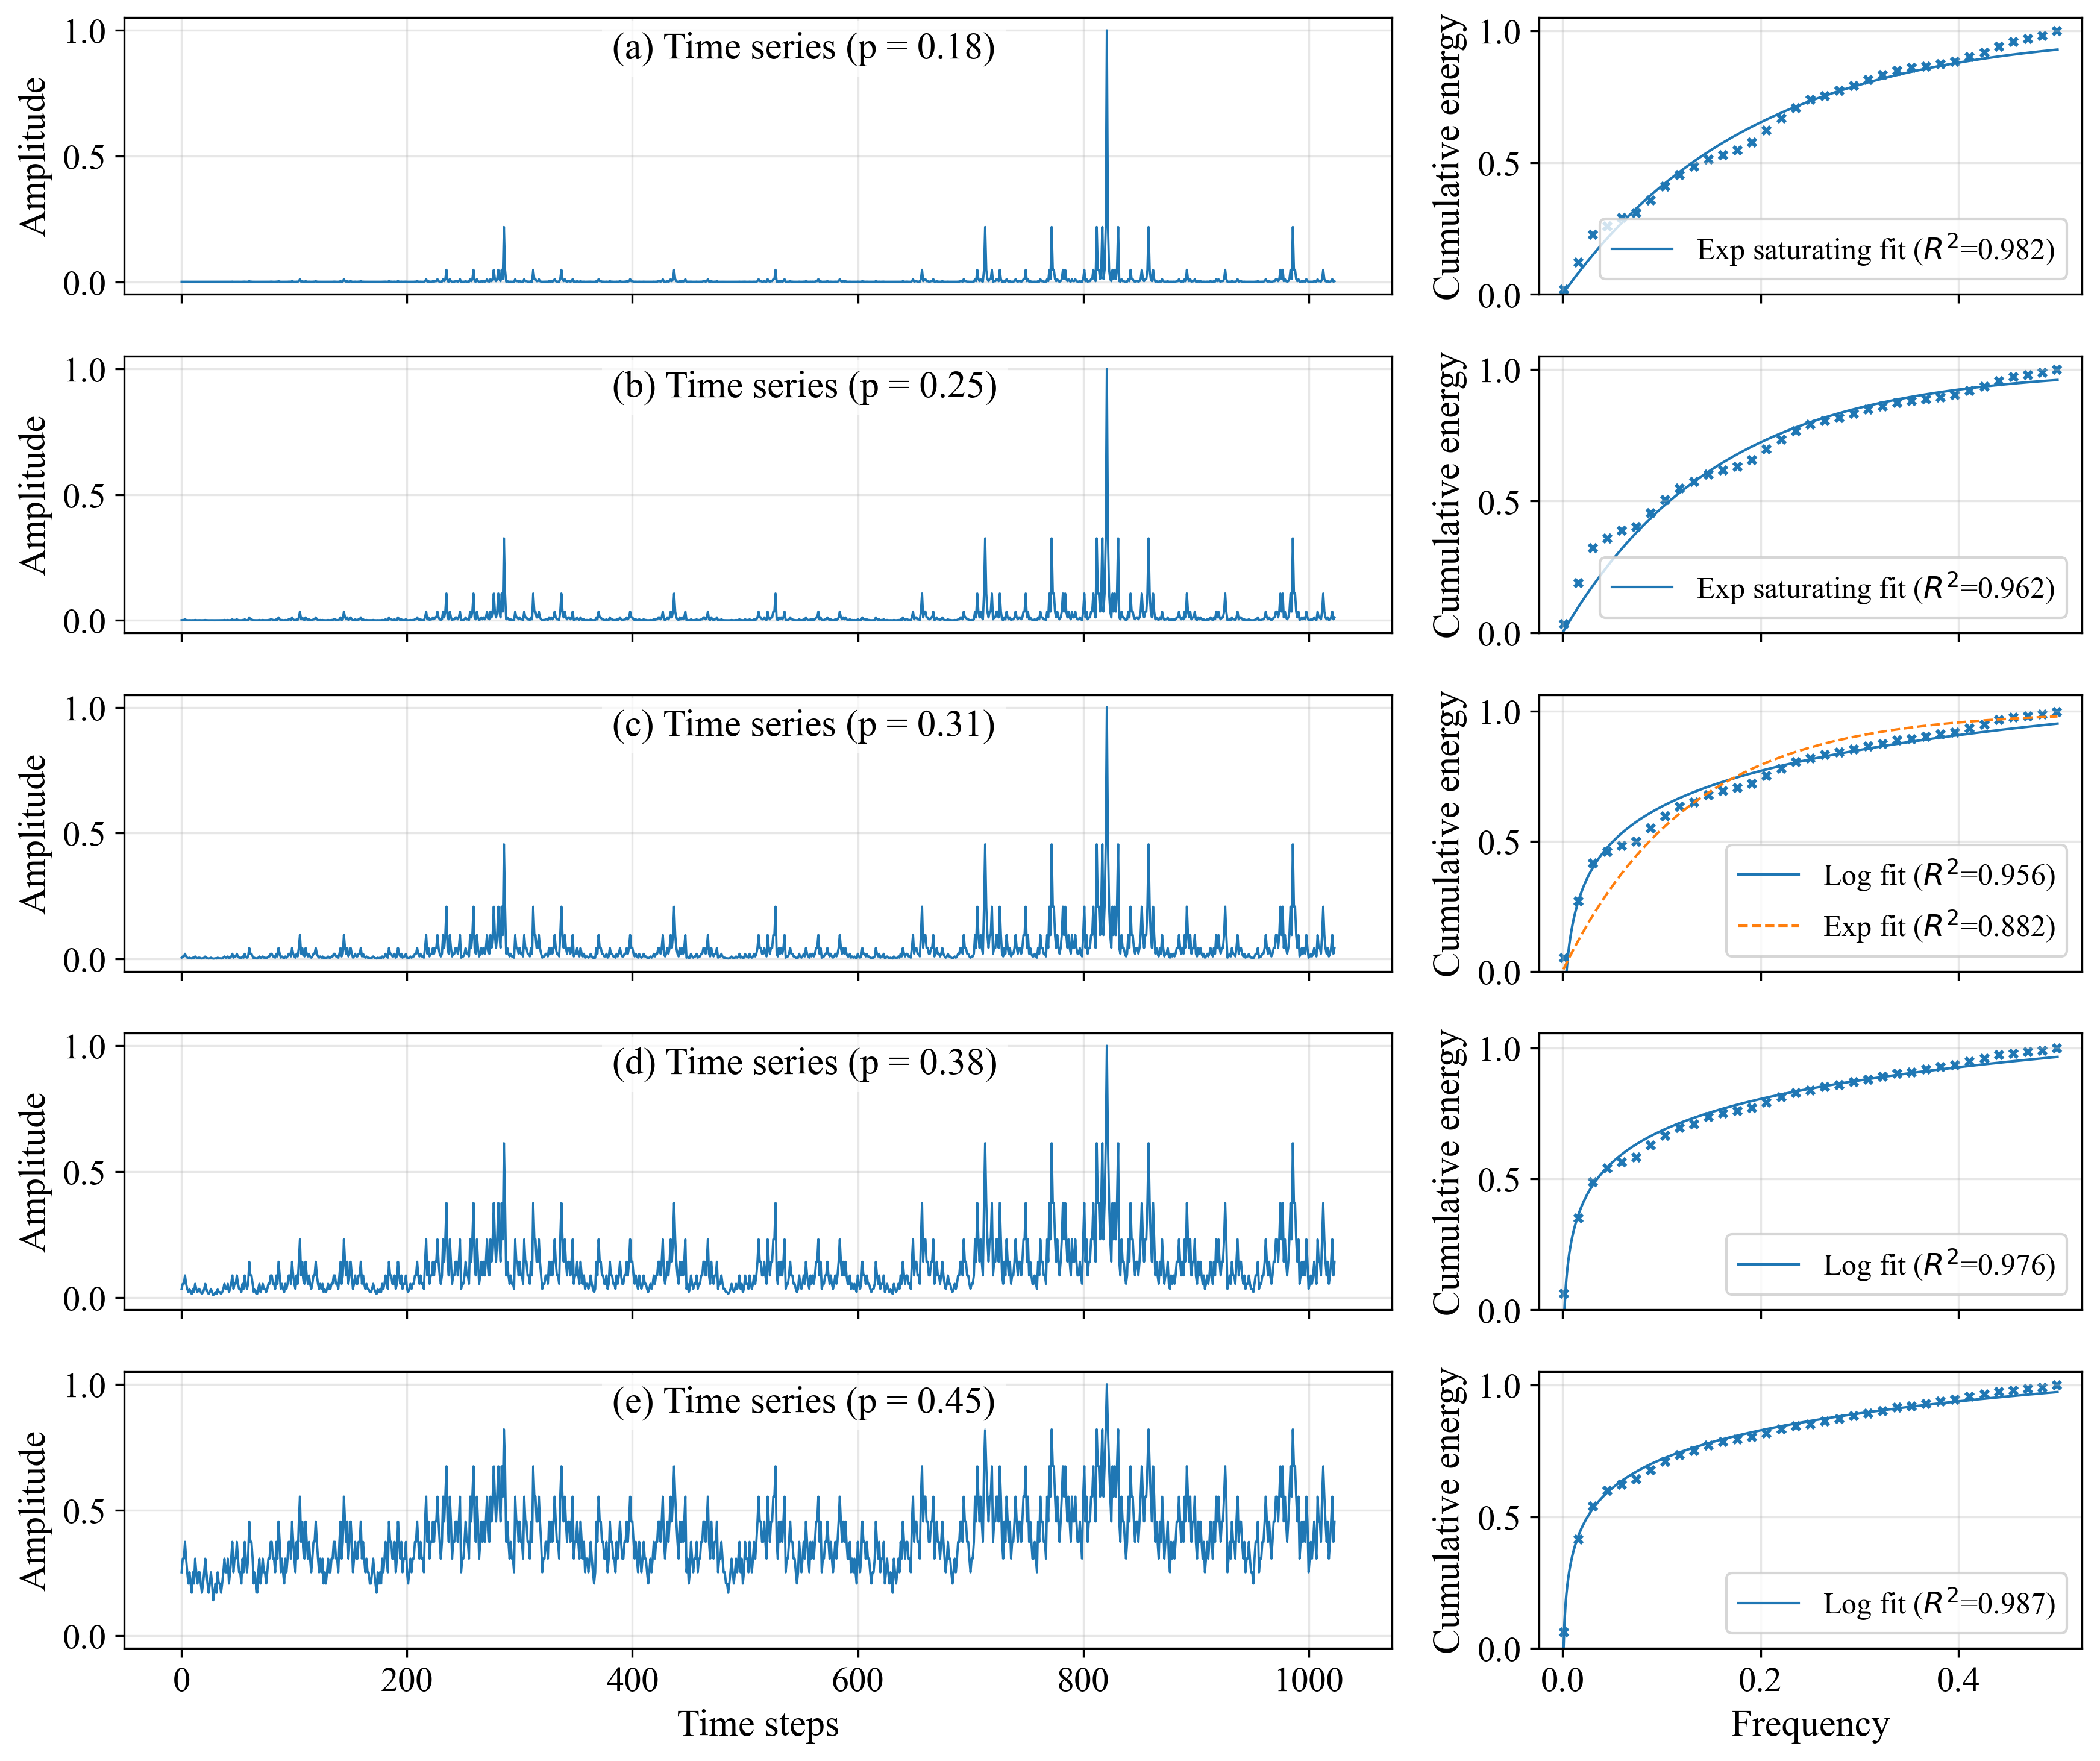

In [276]:
n_series = 5

filtered_series = [(p, serie) for (p, serie, inside) in time_series_pmodel if inside]

indices = np.linspace(0, len(filtered_series) - 1, n_series, dtype=int)
selected_series = [filtered_series[i] for i in indices]

fig, axes = plt.subplots(n_series, 2, figsize=(12, 2*n_series), sharex='col',  gridspec_kw={'width_ratios': [0.7, 0.3]})

if n_series == 1:
    axes = np.array([axes])

middle_idx = n_series // 2

for i, (p_val, serie) in enumerate(selected_series):

    axes[i, 0].plot(normalize(serie), lw=0.9)
    axes[i, 0].set_ylabel("Amplitude")
    margin = 0.05 * (1 - 0)
    axes[i, 0].set_ylim(0 - margin, 1 + margin)
    axes[i, 0].text(
        0.385, 0.95,
        f"({chr(97+i)}) Time series (p = {p_val:.2f})",
        transform=axes[i, 0].transAxes,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )
    axes[i, 0].grid(alpha=0.3)

    if i == middle_idx:
        # retorna ambos os modelos
        results = cumulative_energy_fit(normalize(serie), return_both=True)

        x = results["x"]
        y = results["y"]
        x_fit = results["x_fit"]

        axes[i, 1].scatter(x[::15], y[::15], s=10, marker='x')

        # plot log
        axes[i, 1].plot(
            x_fit,
            results["log"]["y_fit"],
            lw=1,
            label=f"Log fit ($R^2$={results['log']['r2']:.3f})"
        )

        # plot exp
        axes[i, 1].plot(
            x_fit,
            results["exp"]["y_fit"],
            lw=1,
            linestyle="--",
            label=f"Exp fit ($R^2$={results['exp']['r2']:.3f})"
        )

        # axes[i, 1].set_title(f"Fit")

        axes[i, 1].legend()

    else:
        x, y, x_fit, y_fit, best_model, r2_best = cumulative_energy_fit(normalize(serie))

        axes[i, 1].scatter(x[::15], y[::15], s=10, marker='x')
        axes[i, 1].plot(x_fit, y_fit, lw=1, label=f"{best_model} fit ($R^2$={r2_best:.3f})")
        # axes[i, 1].set_title(f"{best_model} fit ($R^2$={r2_best:.3f})")
        axes[i, 1].legend()
    
    axes[i, 1].set_ylim(bottom=0)
    axes[i, 1].set_ylabel("Cumulative energy")
    axes[i, 1].grid(alpha=0.3)

    axes[-1, 0].set_xlabel("Time steps")
    axes[-1, 1].set_xlabel("Frequency")

plt.tight_layout()

plt.savefig("../paper/images/cumulative_energy_fits.png", dpi=300, bbox_inches='tight')  
plt.show()


### Interpretação do gráfico de energia cumulativa

O gráfico mostra como a energia da série temporal está distribuída ao longo das frequências.

No eixo x temos a frequência, e no eixo y a fração acumulada da energia total (normalizada entre 0 e 1).  

Fisicamente, ele indica em quais escalas de tempo a dinâmica do sistema está concentrada:

- Se a curva cresce rapidamente nas baixas frequências, significa que grande parte da energia está associada a variações lentas (estruturas de longo prazo).
- Se a curva cresce de forma mais gradual, isso indica que a energia está distribuída em várias frequências, incluindo componentes de alta frequência (flutuações rápidas).

Assim, o gráfico revela como a variabilidade do sistema se organiza entre oscilações lentas e rápidas, permitindo identificar se a dinâmica é dominada por estruturas de larga escala ou por múltiplas escalas de variação.


In [277]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def cumulative_energy_plot(
    series,
    tau=128*2,
    normalize=True,
    fit_type=None,   # None, 'log', 'exp'
    show_fit=True
):
    """
    Calcula e plota a energia cumulativa por janelas.

    Parâmetros
    ----------
    series : array-like
        Série temporal C(t)
    tau : int
        Tamanho da janela
    normalize : bool
        Se True, normaliza pelo valor máximo
    fit_type : str
        None, 'log' ou 'exp'
    show_fit : bool
        Se True, plota o ajuste
    """

    series = np.array(series)
    n = len(series)

    # Número de blocos completos
    n_blocks = n // tau

    # Corta excesso
    trimmed = series[:n_blocks * tau]

    # Reshape em blocos
    blocks = trimmed.reshape(n_blocks, tau)

    # Média em cada bloco
    energy = blocks.mean(axis=1)

    # Normalização
    if normalize:
        energy = energy / np.max(energy)

    x = np.arange(1, len(energy) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(x, energy, 'o-', label='Energia cumulativa')

    # ======================
    # Ajustes opcionais
    # ======================
    if fit_type == 'log':
        def log_func(x, a, b):
            return a * np.log(x) + b

        popt, _ = curve_fit(log_func, x, energy)
        if show_fit:
            plt.plot(x, log_func(x, *popt), '--',
                     label=f'Ajuste log')

    elif fit_type == 'exp':
        def exp_func(x, a, b):
            return a * np.exp(b * x)

        popt, _ = curve_fit(exp_func, x, energy)
        if show_fit:
            plt.plot(x, exp_func(x, *popt), '--',
                     label=f'Ajuste exp')

    plt.xlabel("Índice da janela")
    plt.ylabel("Energia cumulativa normalizada")
    plt.title("Energia cumulativa por janelas")
    plt.legend()
    plt.grid(True)
    plt.show()

    return energy


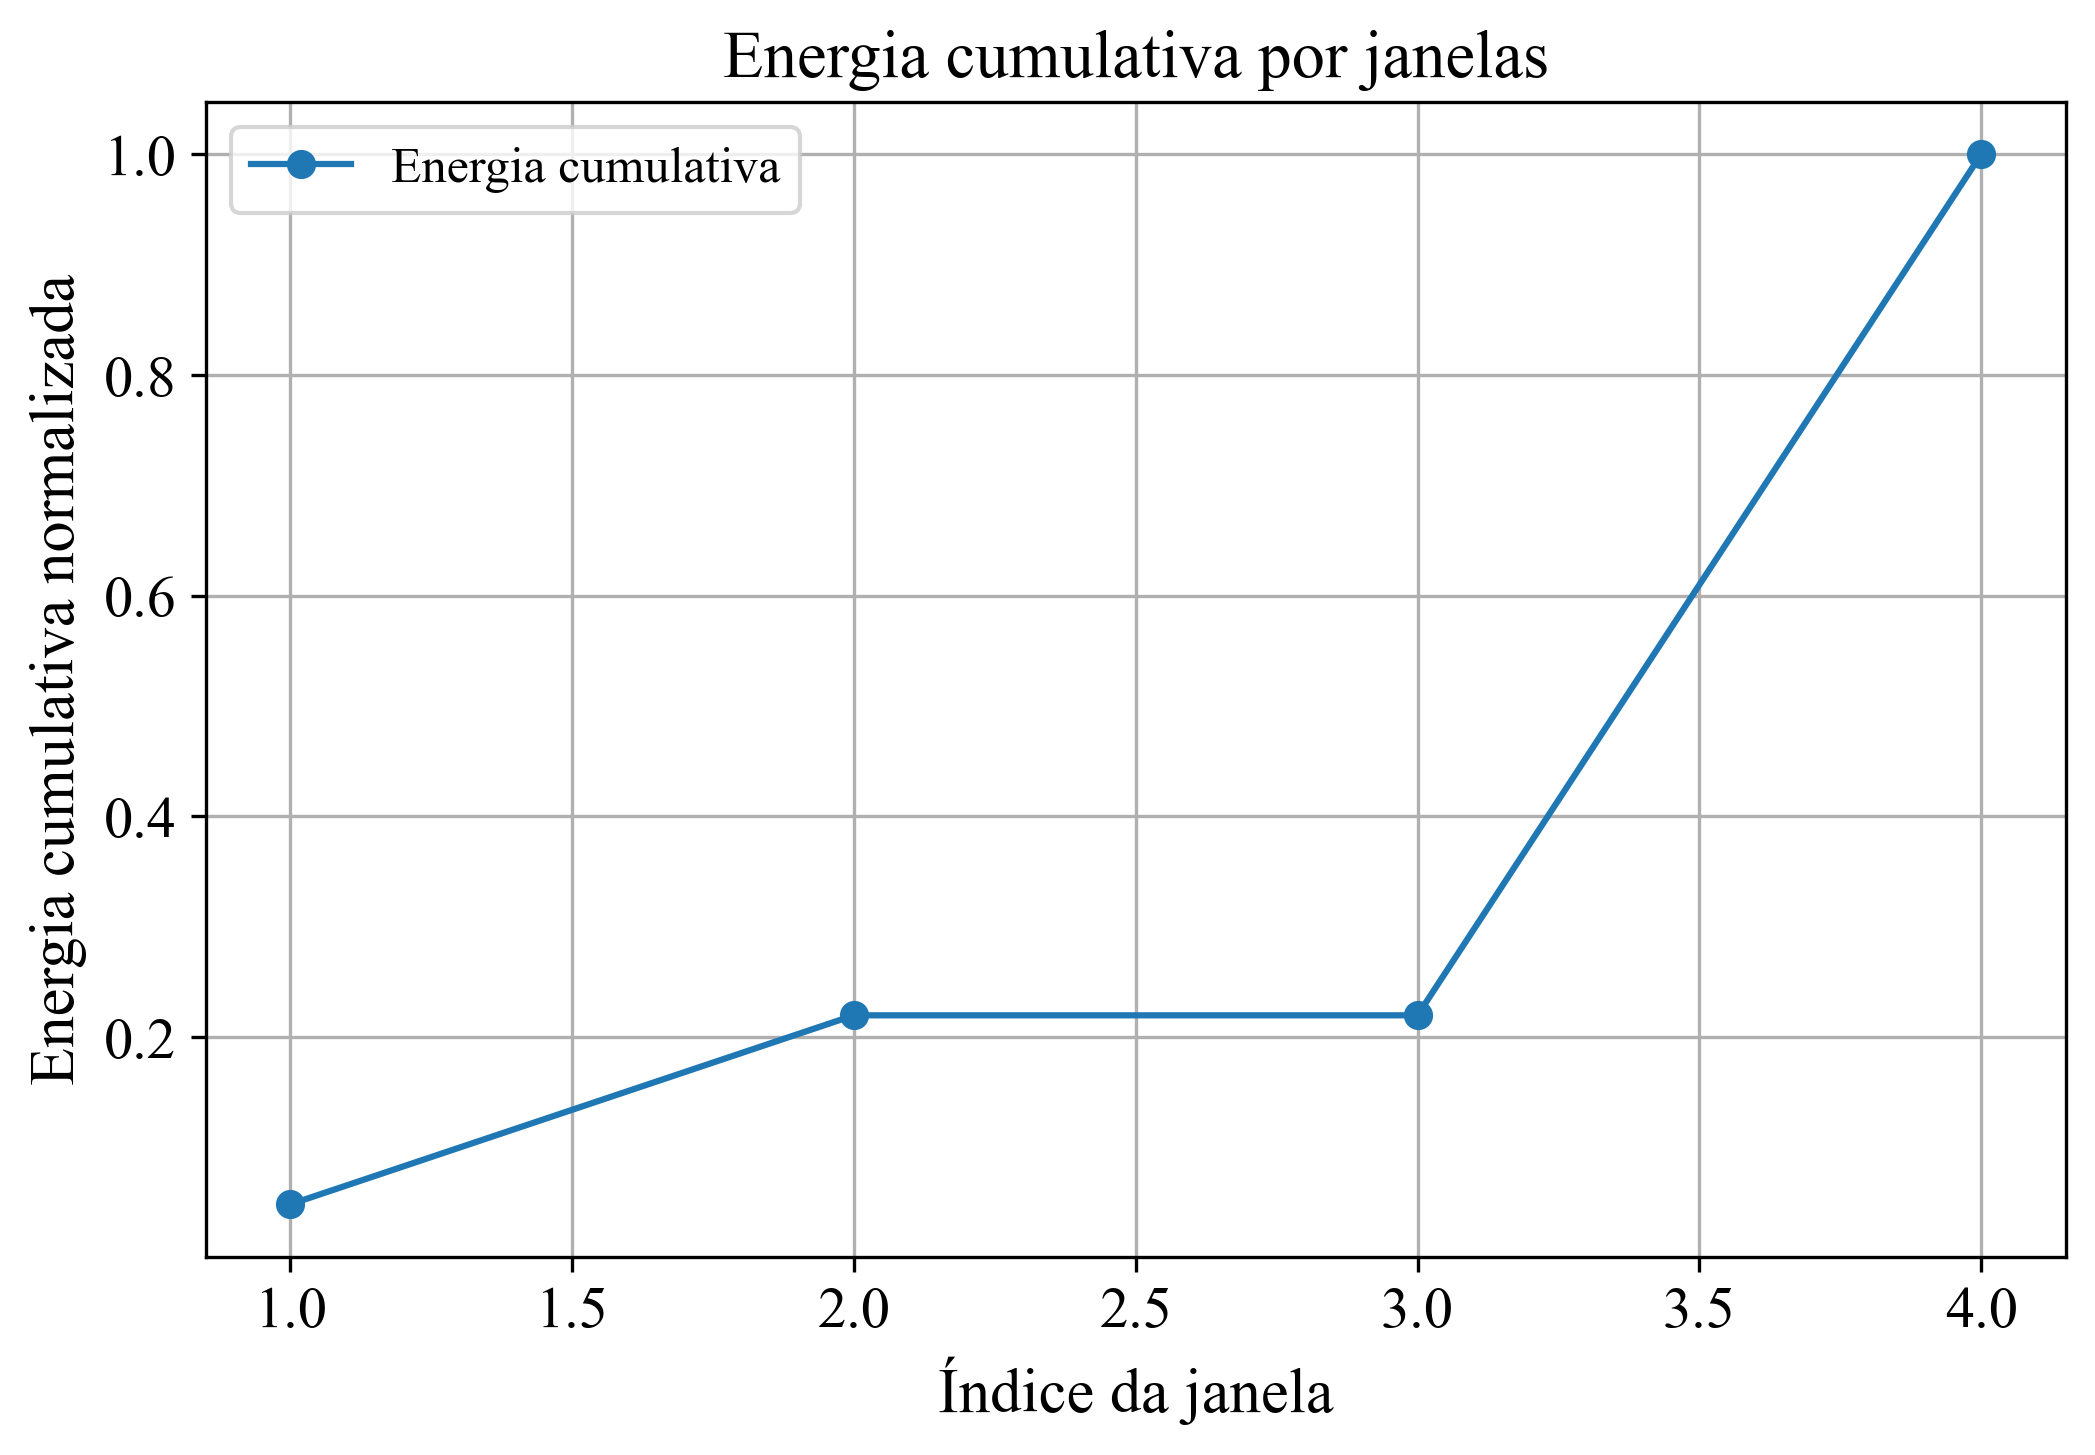

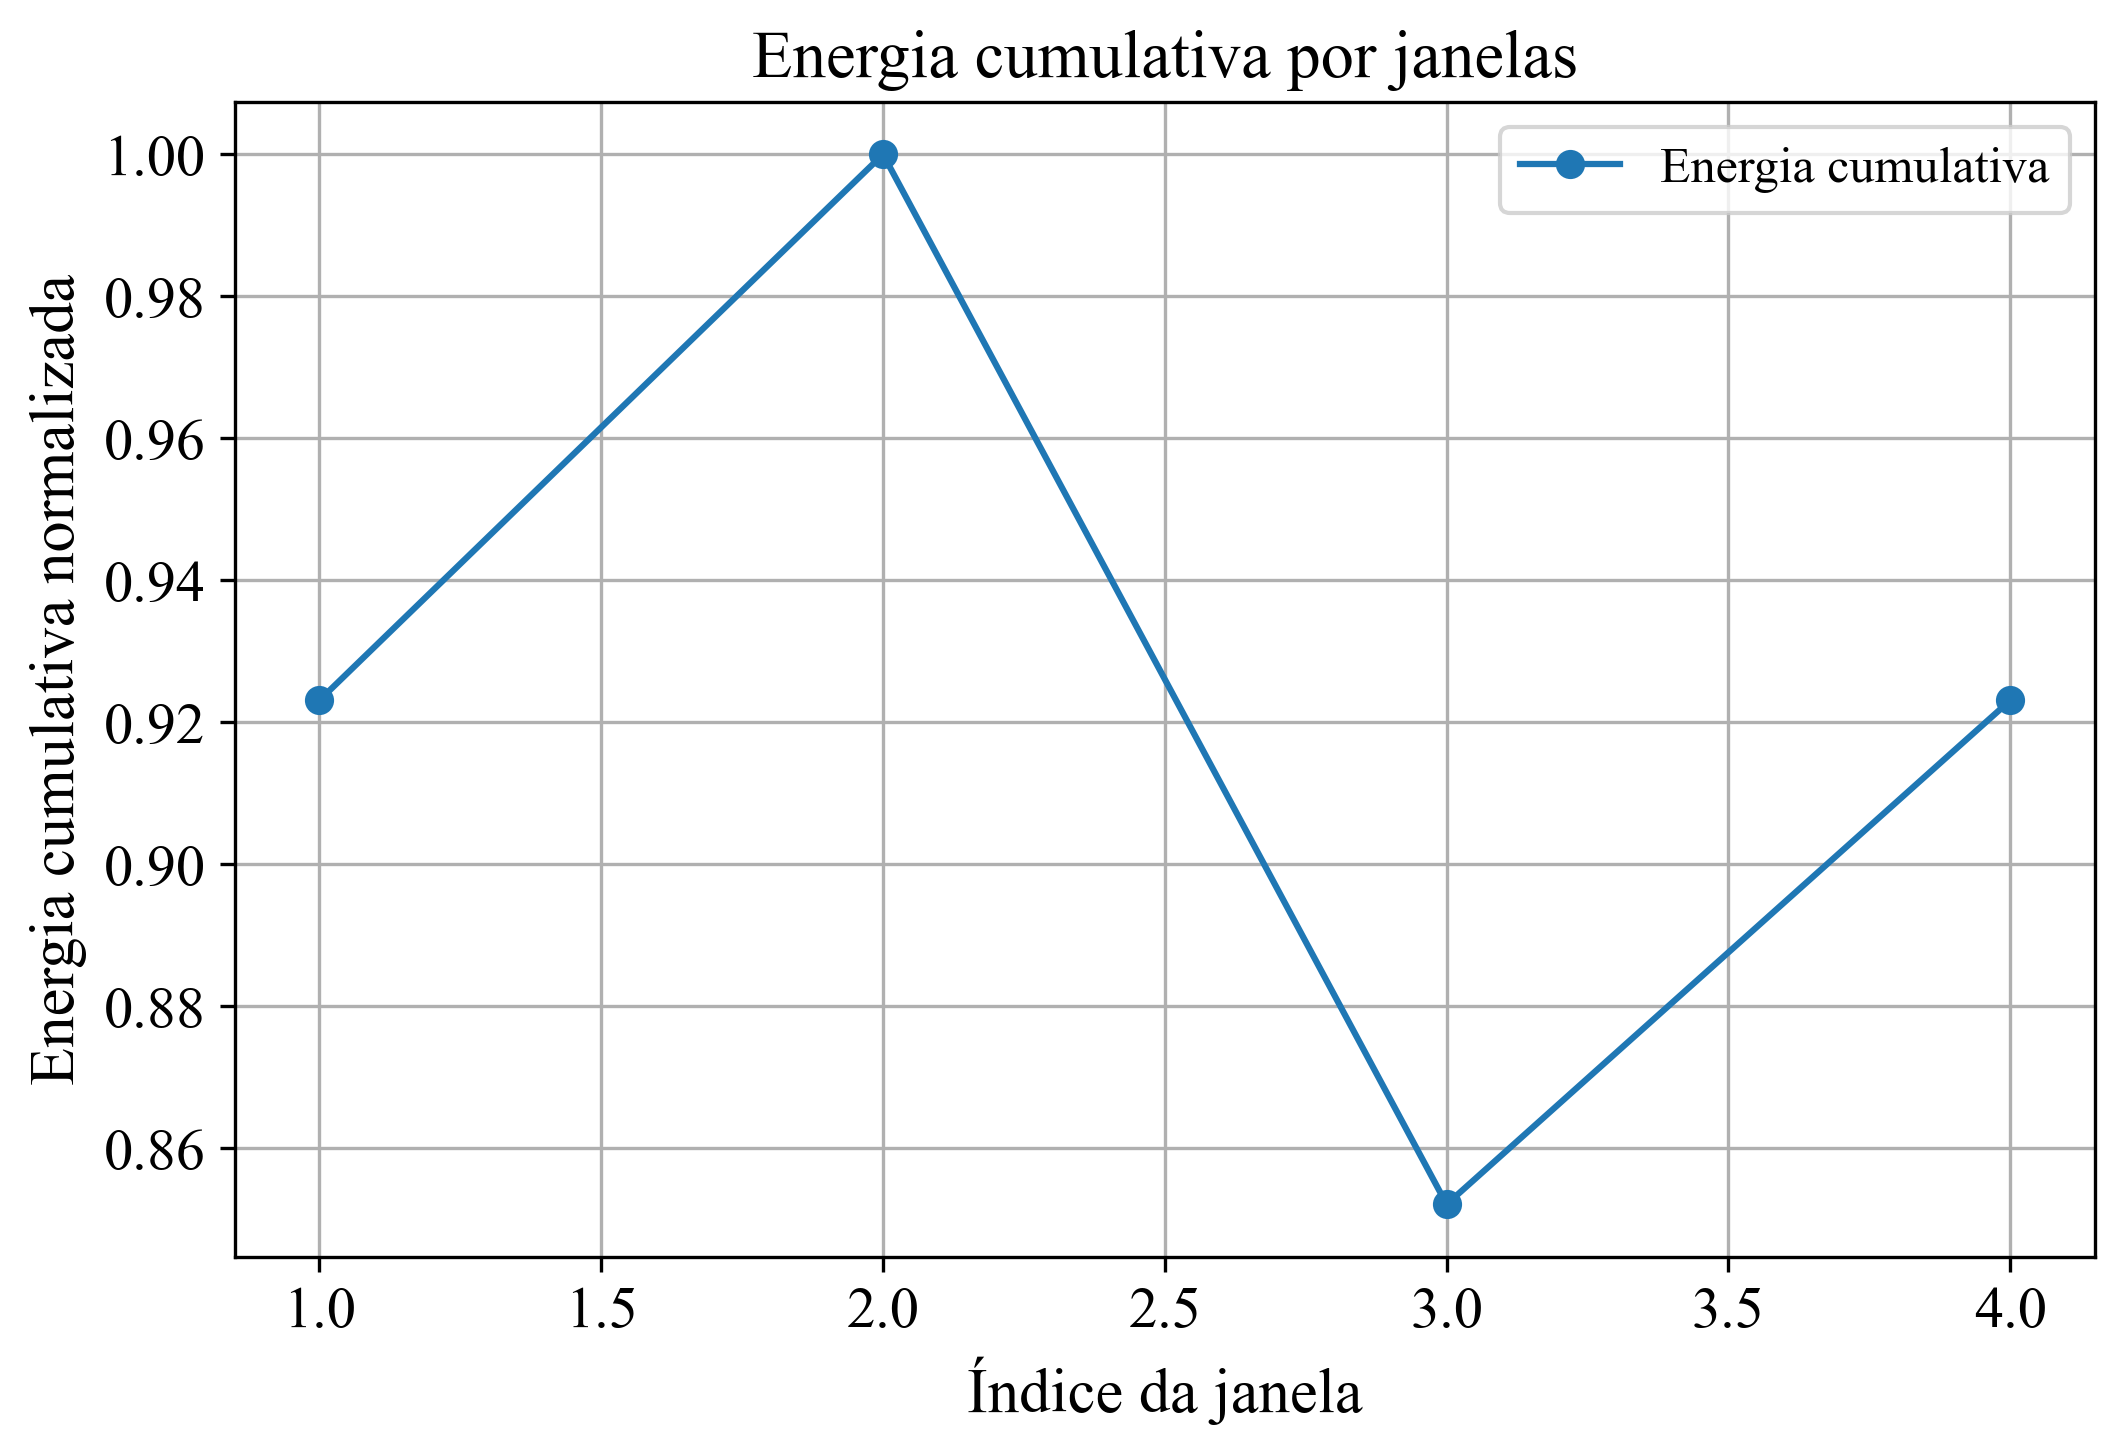

array([0.92307692, 1.        , 0.85207101, 0.92307692])

In [278]:
np.random.seed(126)
y, dy = pmodel(1024, 0.18, 2)
cumulative_energy_plot(dy)
y, dy = pmodel(1024, 0.48, 2)
cumulative_energy_plot(dy)

In [279]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def multifractal_spectrum(signal, q_vals, scales):

    N = len(signal)
    signal = np.abs(signal)  # ou use sua medida (ex: dissipação)

    alphas = []
    fqs = []

    for q in q_vals:

        num_alpha = []
        num_f = []
        log_scales = []

        for r in scales:

            n_boxes = N // r
            if n_boxes < 2:
                continue

            # Box averaging
            boxes = signal[:n_boxes*r].reshape((n_boxes, r))
            mu = boxes.sum(axis=1)
            mu = mu / mu.sum()

            # Evita zeros
            mu = mu[mu > 0]

            if len(mu) < 2:
                continue

            if q == 1:
                P = mu
            else:
                P = mu**q
                P = P / P.sum()

            num_alpha.append(np.sum(P * np.log(mu)))
            num_f.append(np.sum(P * np.log(P)))
            log_scales.append(np.log(r))

        # Regressão linear
        slope_alpha, _, _, _, _ = linregress(log_scales, num_alpha)
        slope_f, _, _, _, _ = linregress(log_scales, num_f)

        alphas.append(slope_alpha)
        fqs.append(slope_f)

    return np.array(alphas), np.array(fqs)


In [280]:
from scipy import stats

def DFA(signal, scale_min=4, scale_max=100, scale_density=20):
    N = len(signal)
    signal = np.array(signal)
    Y = np.cumsum(signal - np.mean(signal))
    scales = np.logspace(np.log10(scale_min), np.log10(scale_max), num=scale_density).astype(int)
    scales = np.unique(scales)
    fluct = []

    for s in scales:
        n_segments = N // s
        RMS = []
        for i in range(n_segments):
            idx_start = i * s
            idx_end = idx_start + s
            segment = Y[idx_start:idx_end]
            C = np.polyfit(range(s), segment, 1)
            fit = np.polyval(C, range(s))
            RMS.append(np.sqrt(np.mean((segment - fit) ** 2)))
        fluct.append(np.sqrt(np.mean(np.array(RMS) ** 2)))
    
    log_scales = np.log10(scales)
    log_fluct = np.log10(fluct)
    slope_dfa, _, _, _, _ = stats.linregress(log_scales, log_fluct)
    return slope_dfa

In [281]:
from scipy.signal import welch

def PSD(signal):
    freqs, psd = welch(signal, nperseg=len(signal)//4)
    slope_psd, _, _, _, _ = stats.linregress(np.log(freqs[1:]), np.log(psd[1:]))
    beta_psd = -slope_psd
    return beta_psd

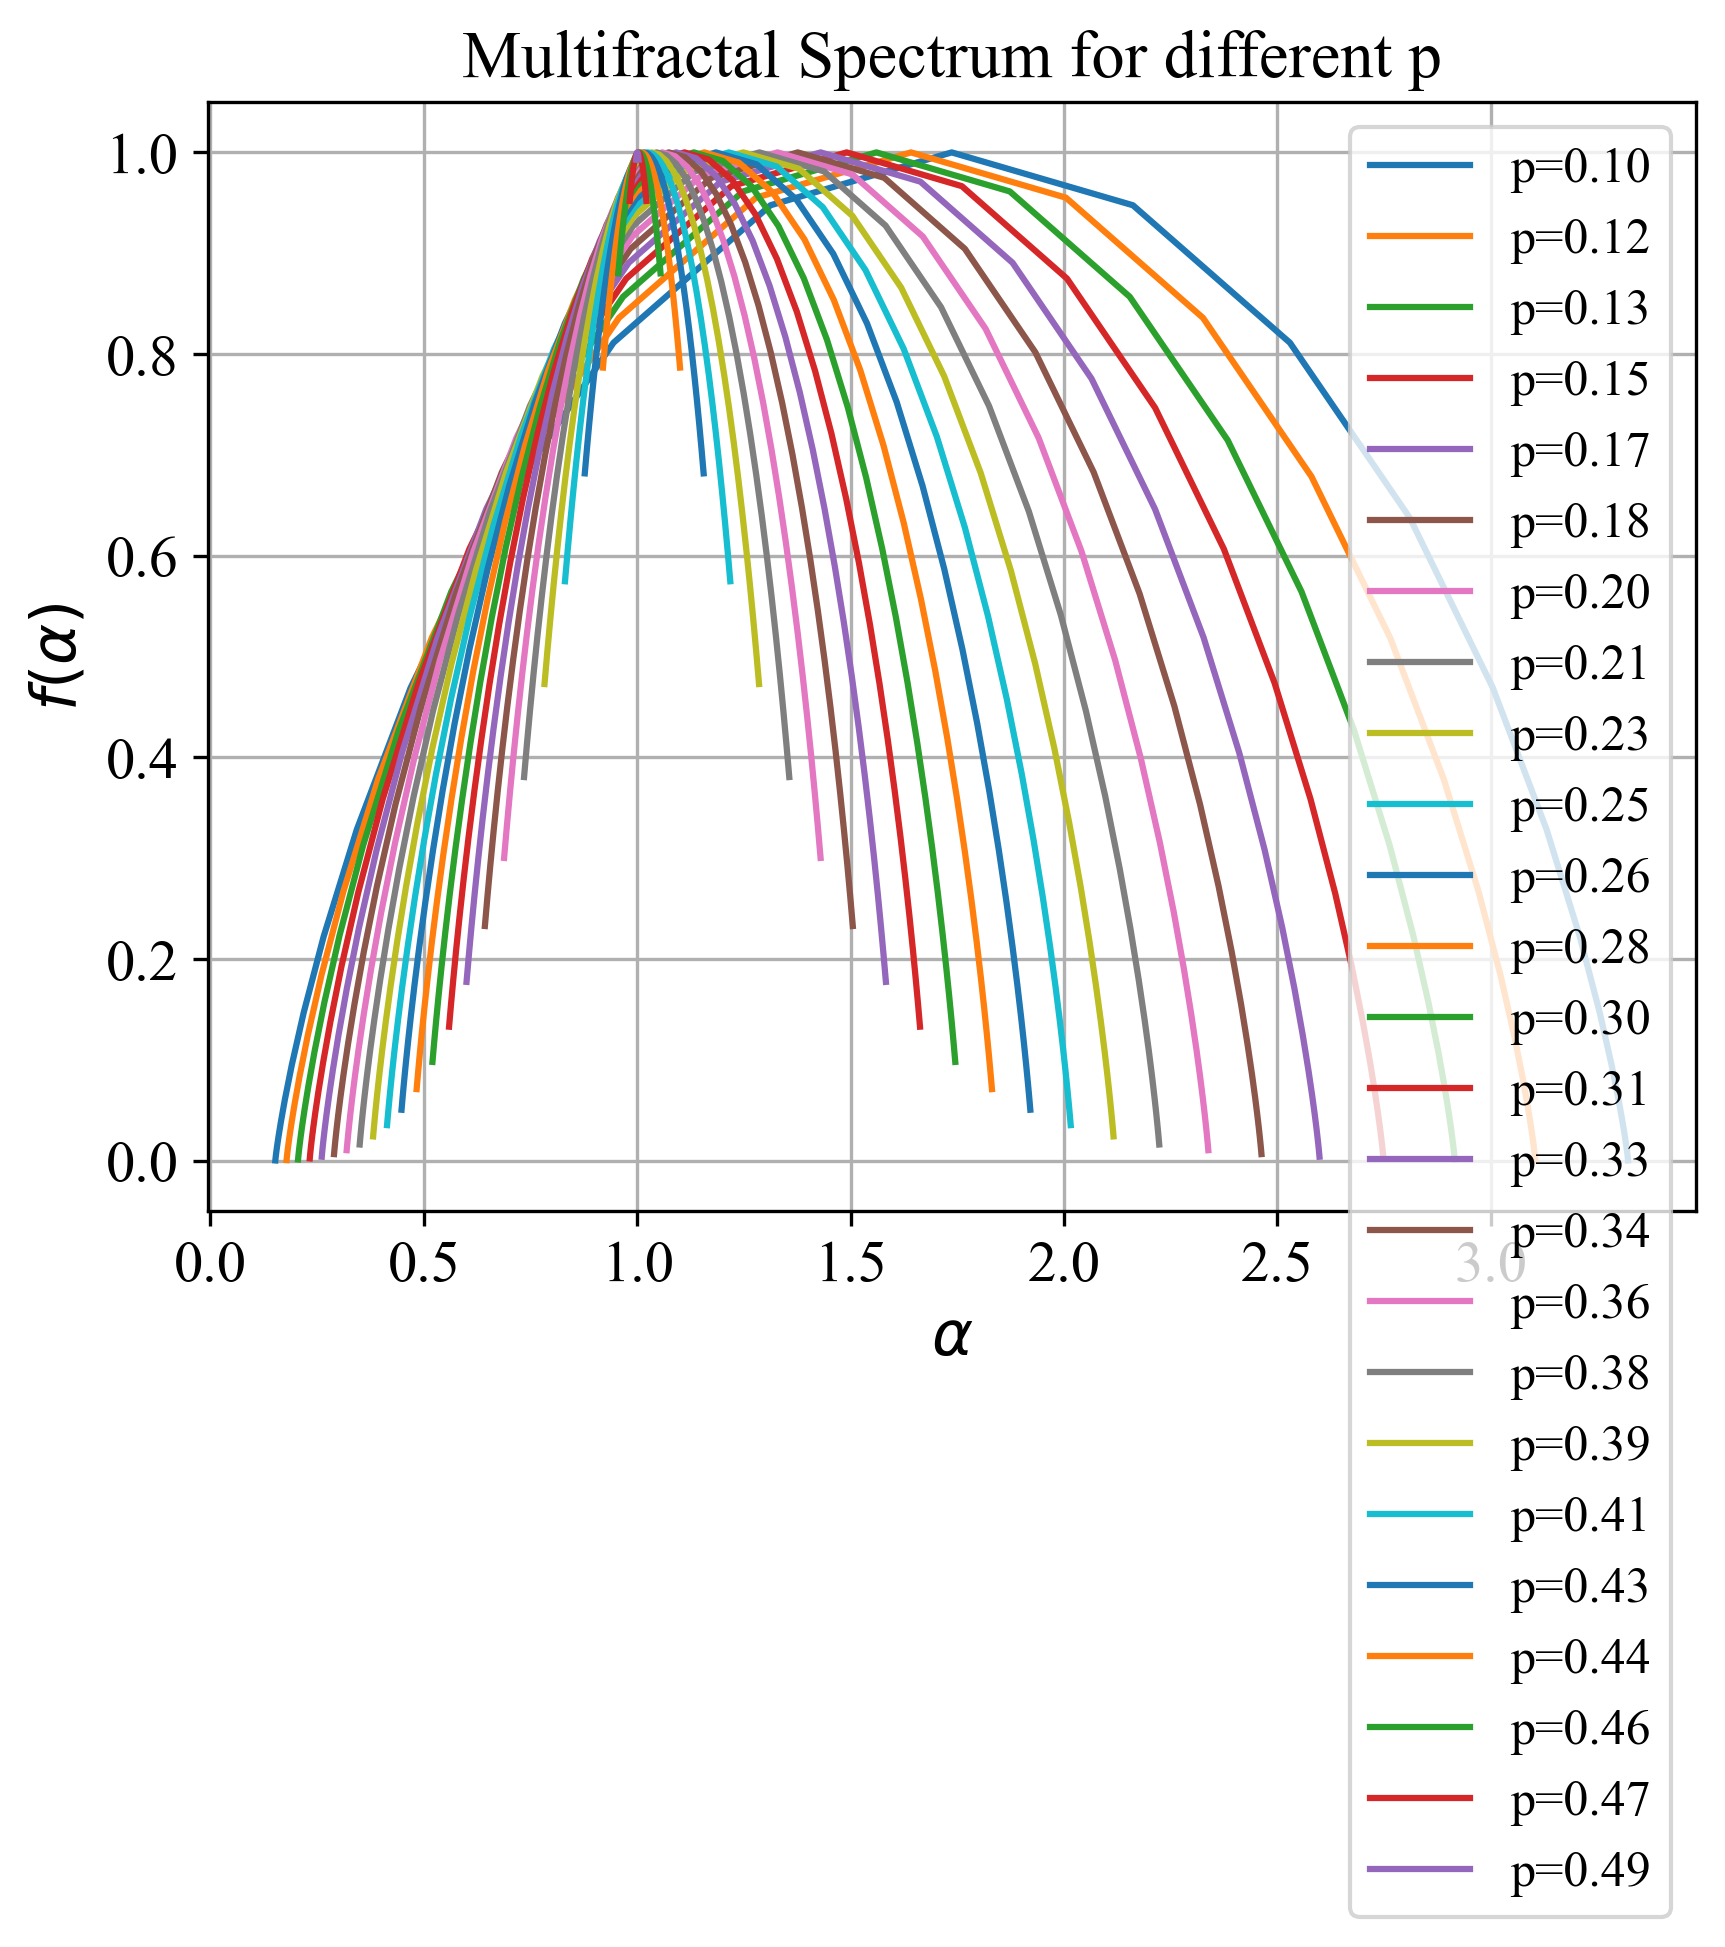

In [282]:
N = 1024

def normalize(x):
    return x / (np.sum(x) + 1e-12)

scales = 2**np.arange(2, int(np.log2(N)) - 2)
q_vals = np.linspace(-5, 5, 41)
p_values = np.linspace(0.1, 0.49, 25)

delta_alphas = []
dfa_exponents = []
psd_exponents = []

for p in p_values:
    np.random.seed(9)
    
    y, dy = pmodel(N, p, 2)
    measure = normalize(dy)
    
    # ---- MULTIFRACTAL ----
    alpha, f = multifractal_spectrum(measure, q_vals, scales)
    
    valid = ~np.isnan(alpha)
    alpha_valid = alpha[valid]
    
    cut = int(0.1 * len(alpha_valid))
    alpha_core = alpha_valid[cut:-cut] if cut > 0 else alpha_valid
    
    delta_alpha = np.max(alpha_core) - np.min(alpha_core)
    delta_alphas.append(delta_alpha)
    
    # ---- DFA ----
    alpha_dfa = DFA(measure, scales)
    dfa_exponents.append(alpha_dfa)
    
    # ---- PSD ----
    beta_psd = PSD(measure)
    psd_exponents.append(beta_psd)
    
    plt.plot(alpha, f, label=f'p={p:.2f}')

plt.xlabel(r'$\alpha$')
plt.ylabel(r'$f(\alpha)$')
plt.title("Multifractal Spectrum for different p")
plt.legend()
plt.grid(True)
plt.show()

delta_alphas = np.array(delta_alphas)
dfa_exponents = np.array(dfa_exponents)
psd_exponents = np.array(psd_exponents)


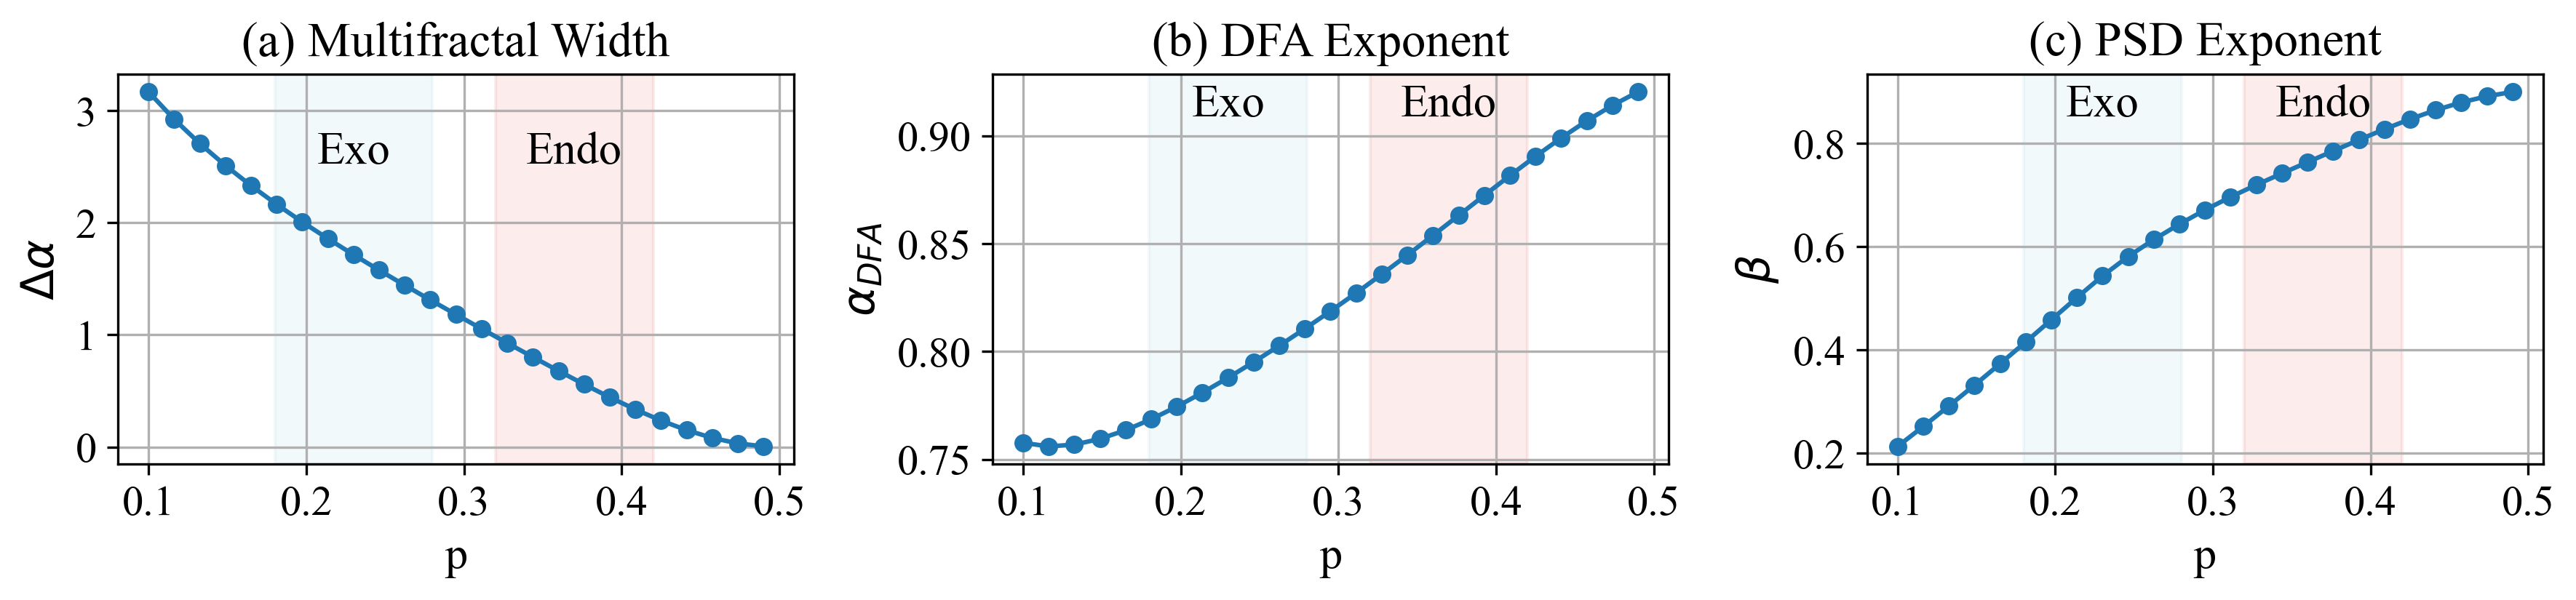

In [297]:
plt.figure(figsize=(12,3))

# -------- 1 --------
ax1 = plt.subplot(1,3,1)

ax1.axvspan(0.18, 0.28, color='lightblue', alpha=0.15)
ax1.axvspan(0.32, 0.42, color='lightcoral', alpha=0.15)

ax1.text(0.23, 0.80, 'Exo',
         transform=ax1.get_xaxis_transform(),
         ha='center', va='center')

ax1.text(0.37, 0.80, 'Endo',
         transform=ax1.get_xaxis_transform(),
         ha='center', va='center')

ax1.plot(p_values, delta_alphas, 'o-', markersize=5)
ax1.set_xlabel('p')
ax1.set_ylabel(r'$\Delta \alpha$')
ax1.set_title('(a) Multifractal Width')
ax1.grid(True)


# -------- 2 --------
ax2 = plt.subplot(1,3,2)

ax2.axvspan(0.18, 0.28, color='lightblue', alpha=0.15)
ax2.axvspan(0.32, 0.42, color='lightcoral', alpha=0.15)

ax2.text(0.23, 0.92, 'Exo',
         transform=ax2.get_xaxis_transform(),
         ha='center', va='center')

ax2.text(0.37, 0.92, 'Endo',
         transform=ax2.get_xaxis_transform(),
         ha='center', va='center')

ax2.plot(p_values, dfa_exponents, 'o-', markersize=5)
ax2.set_xlabel('p')
ax2.set_ylabel(r'$\alpha_{DFA}$')
ax2.set_title('(b) DFA Exponent')
ax2.grid(True)


# -------- 3 --------
ax3 = plt.subplot(1,3,3)

ax3.axvspan(0.18, 0.28, color='lightblue', alpha=0.15)
ax3.axvspan(0.32, 0.42, color='lightcoral', alpha=0.15)

ax3.text(0.23, 0.92, 'Exo',
         transform=ax3.get_xaxis_transform(),
         ha='center', va='center')

ax3.text(0.37, 0.92, 'Endo',
         transform=ax3.get_xaxis_transform(),
         ha='center', va='center')

ax3.plot(p_values, psd_exponents, 'o-', markersize=5)
ax3.set_xlabel('p')
ax3.set_ylabel(r'$\beta$')
ax3.set_title('(c) PSD Exponent')
ax3.grid(True)

plt.tight_layout()

plt.savefig("../paper/images/scaling_exponents_vs_p.png", dpi=300, bbox_inches='tight')  
plt.show()

Δα pequeno
Sistema quase homogêneo
Estrutura quase monofractal
Baixa intermittência
Distribuição relativamente uniforme

Δα grande
Sistema muito heterogêneo
Muitas intensidades locais diferentes
Forte intermittência
Concentração extrema da medida

In [284]:
import numpy as np

# Índice do valor máximo
idx_max = np.argmax(df_exo)

# Valor máximo
val_max = np.max(df_exo)

print(f"Valor máximo: {val_max}, posição: {idx_max}")


Valor máximo: 0.9999999997060744, posição: 57


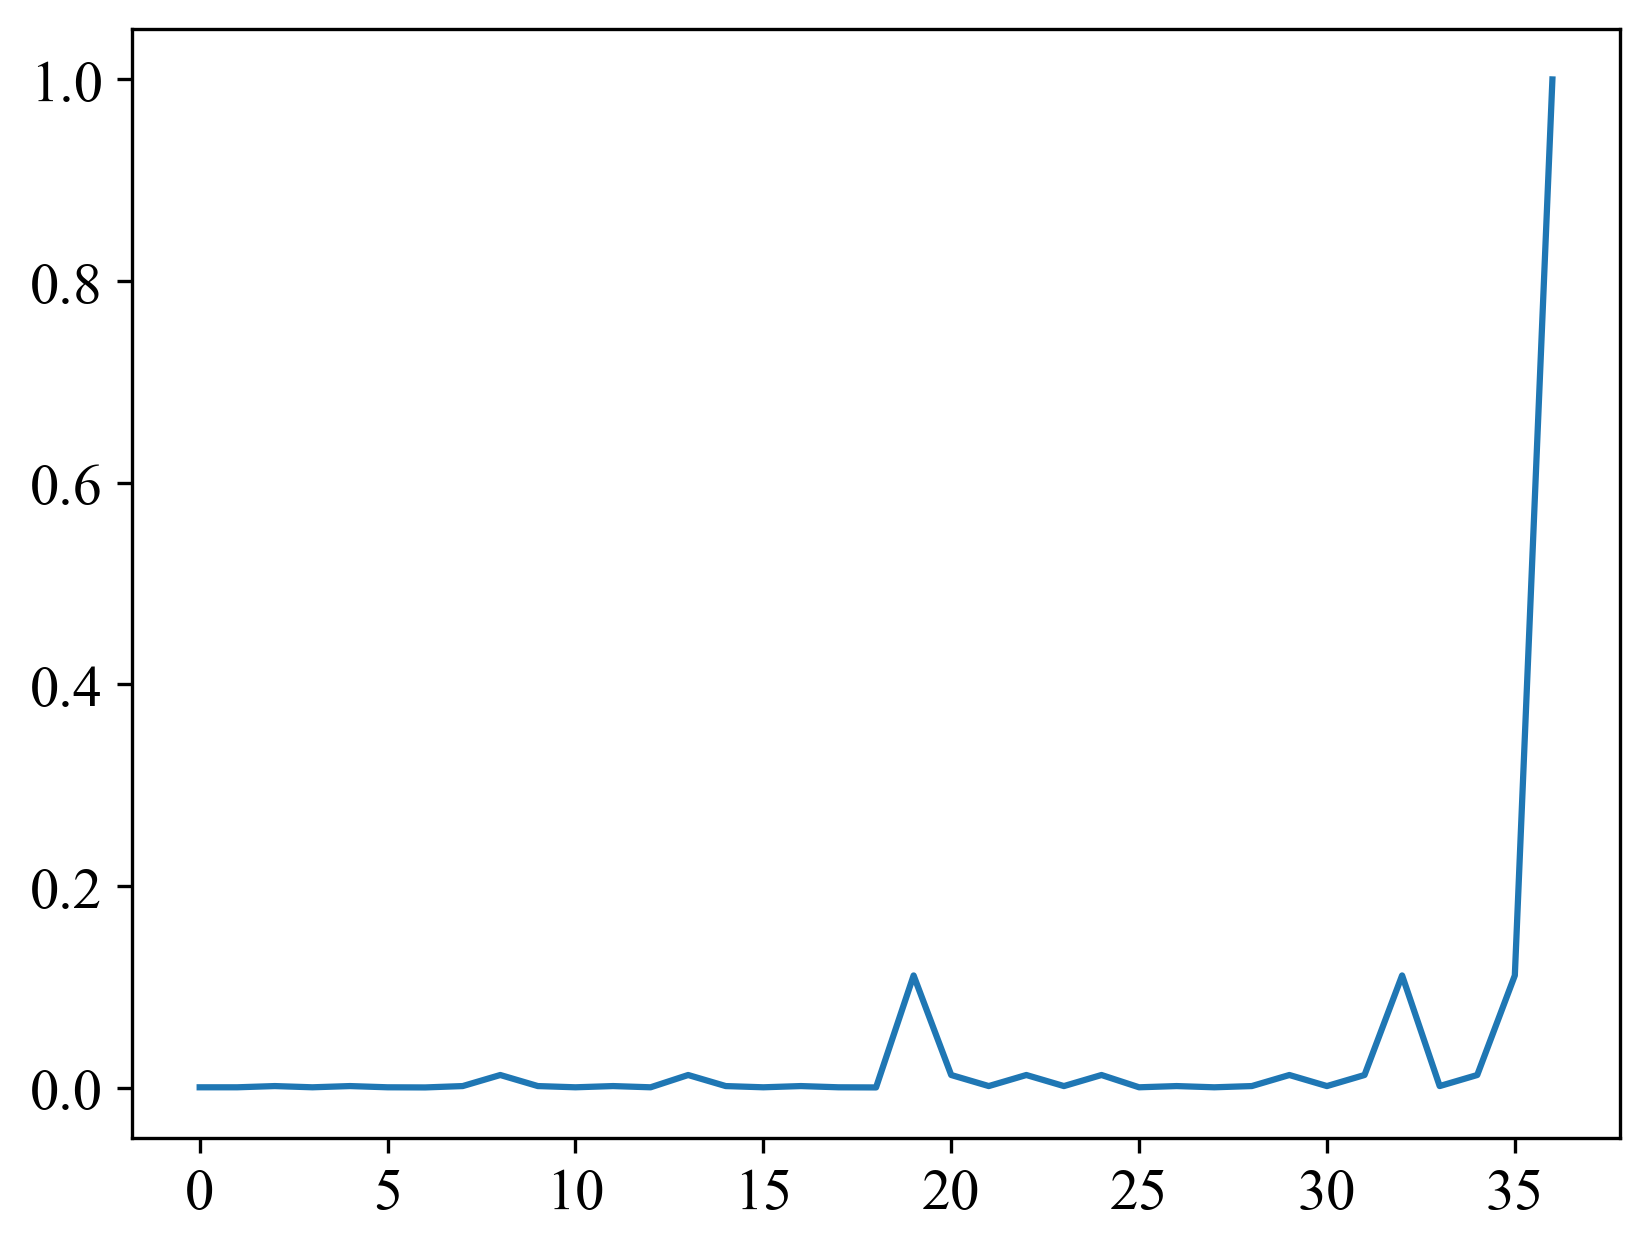

In [285]:
window_size = 100
before = df_exo[idx_max-window_size:idx_max+1]
plt.plot(before)

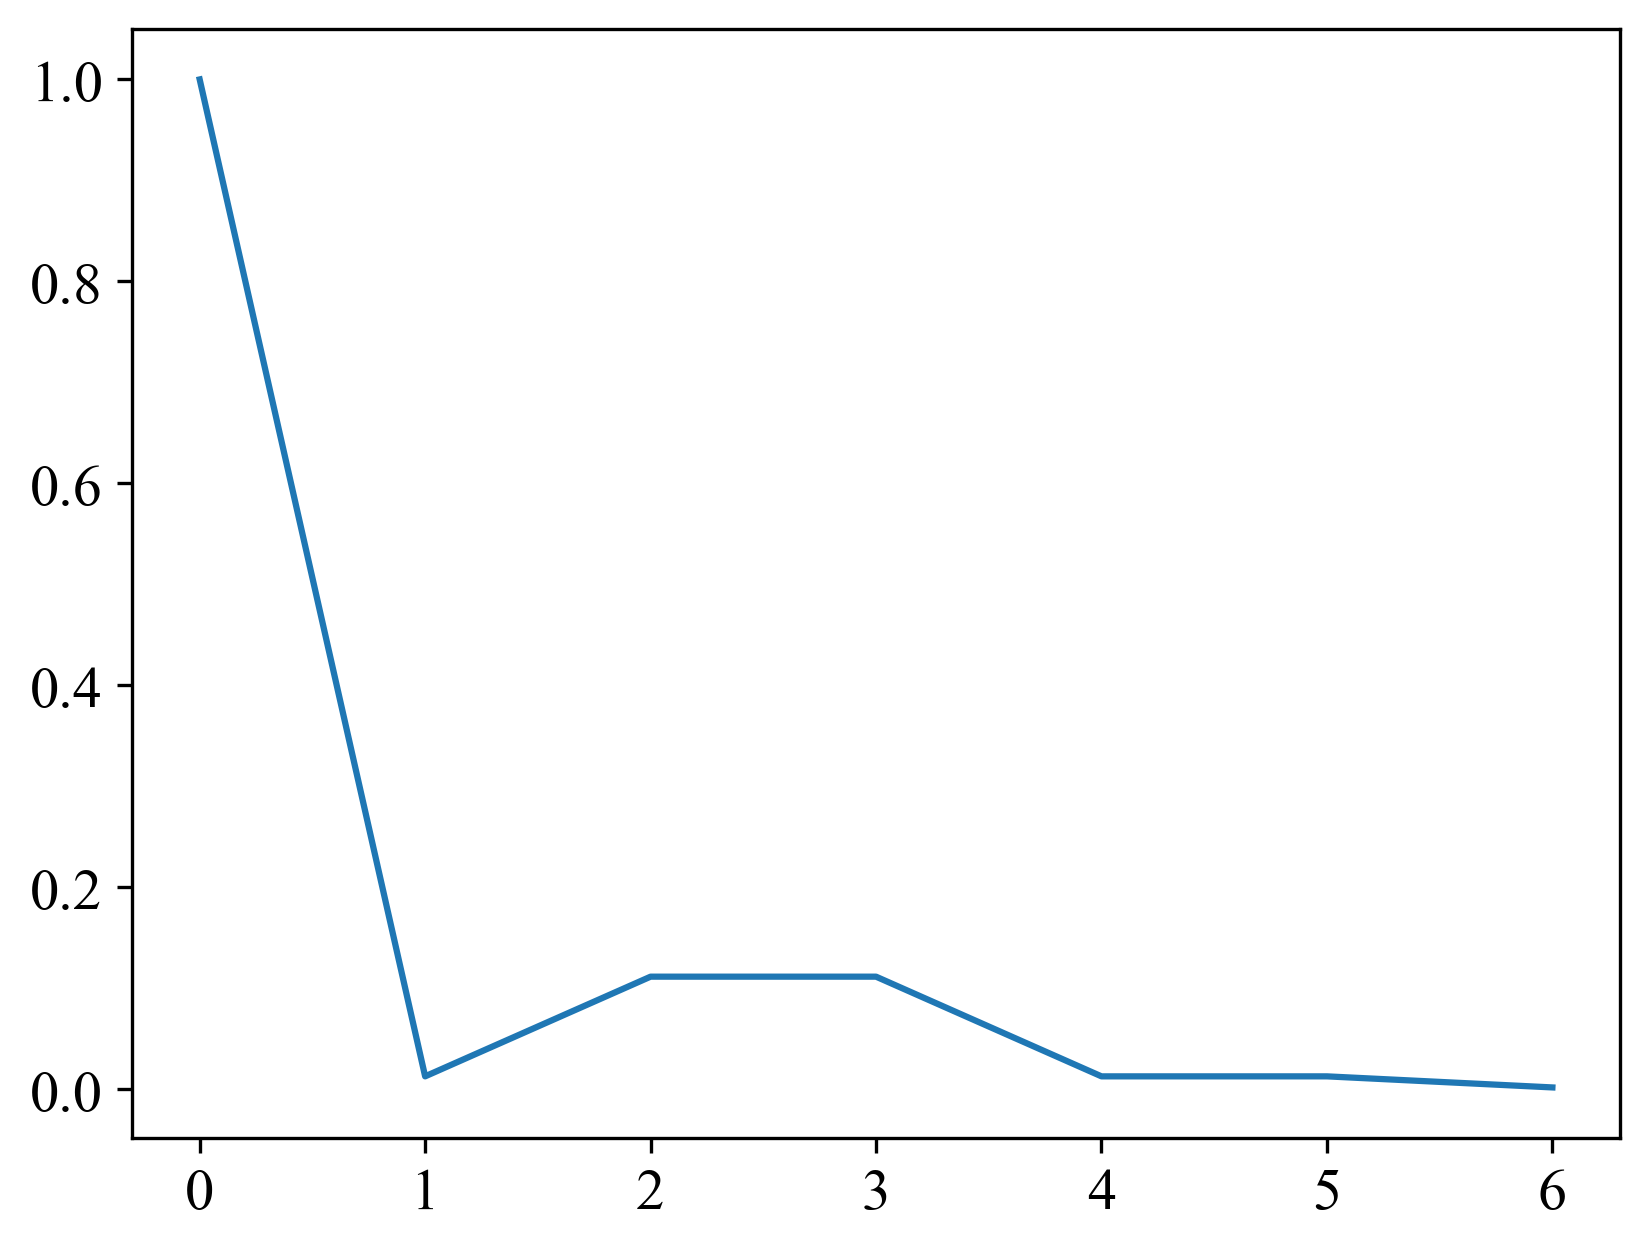

In [286]:
window_size = 100
after = df_exo[idx_max:idx_max+1+window_size]
plt.plot(after)

In [287]:
import numpy as np

x = np.array(after)
x = x[x > 0]  # excluir zeros (log não existe)


In [288]:
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 20)  # 20 bins log
hist, bin_edges = np.histogram(x, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# apenas bins com contagem > 0
mask = hist > 0
log_x = np.log10(bin_centers[mask])
log_y = np.log10(hist[mask])


In [289]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
gamma = -slope  # expoente da lei de potência

print(f"Expoente da lei de potência (γ) = {gamma:.2f}, R² = {r_value**2:.2f}")


Expoente da lei de potência (γ) = 1.27, R² = 1.00


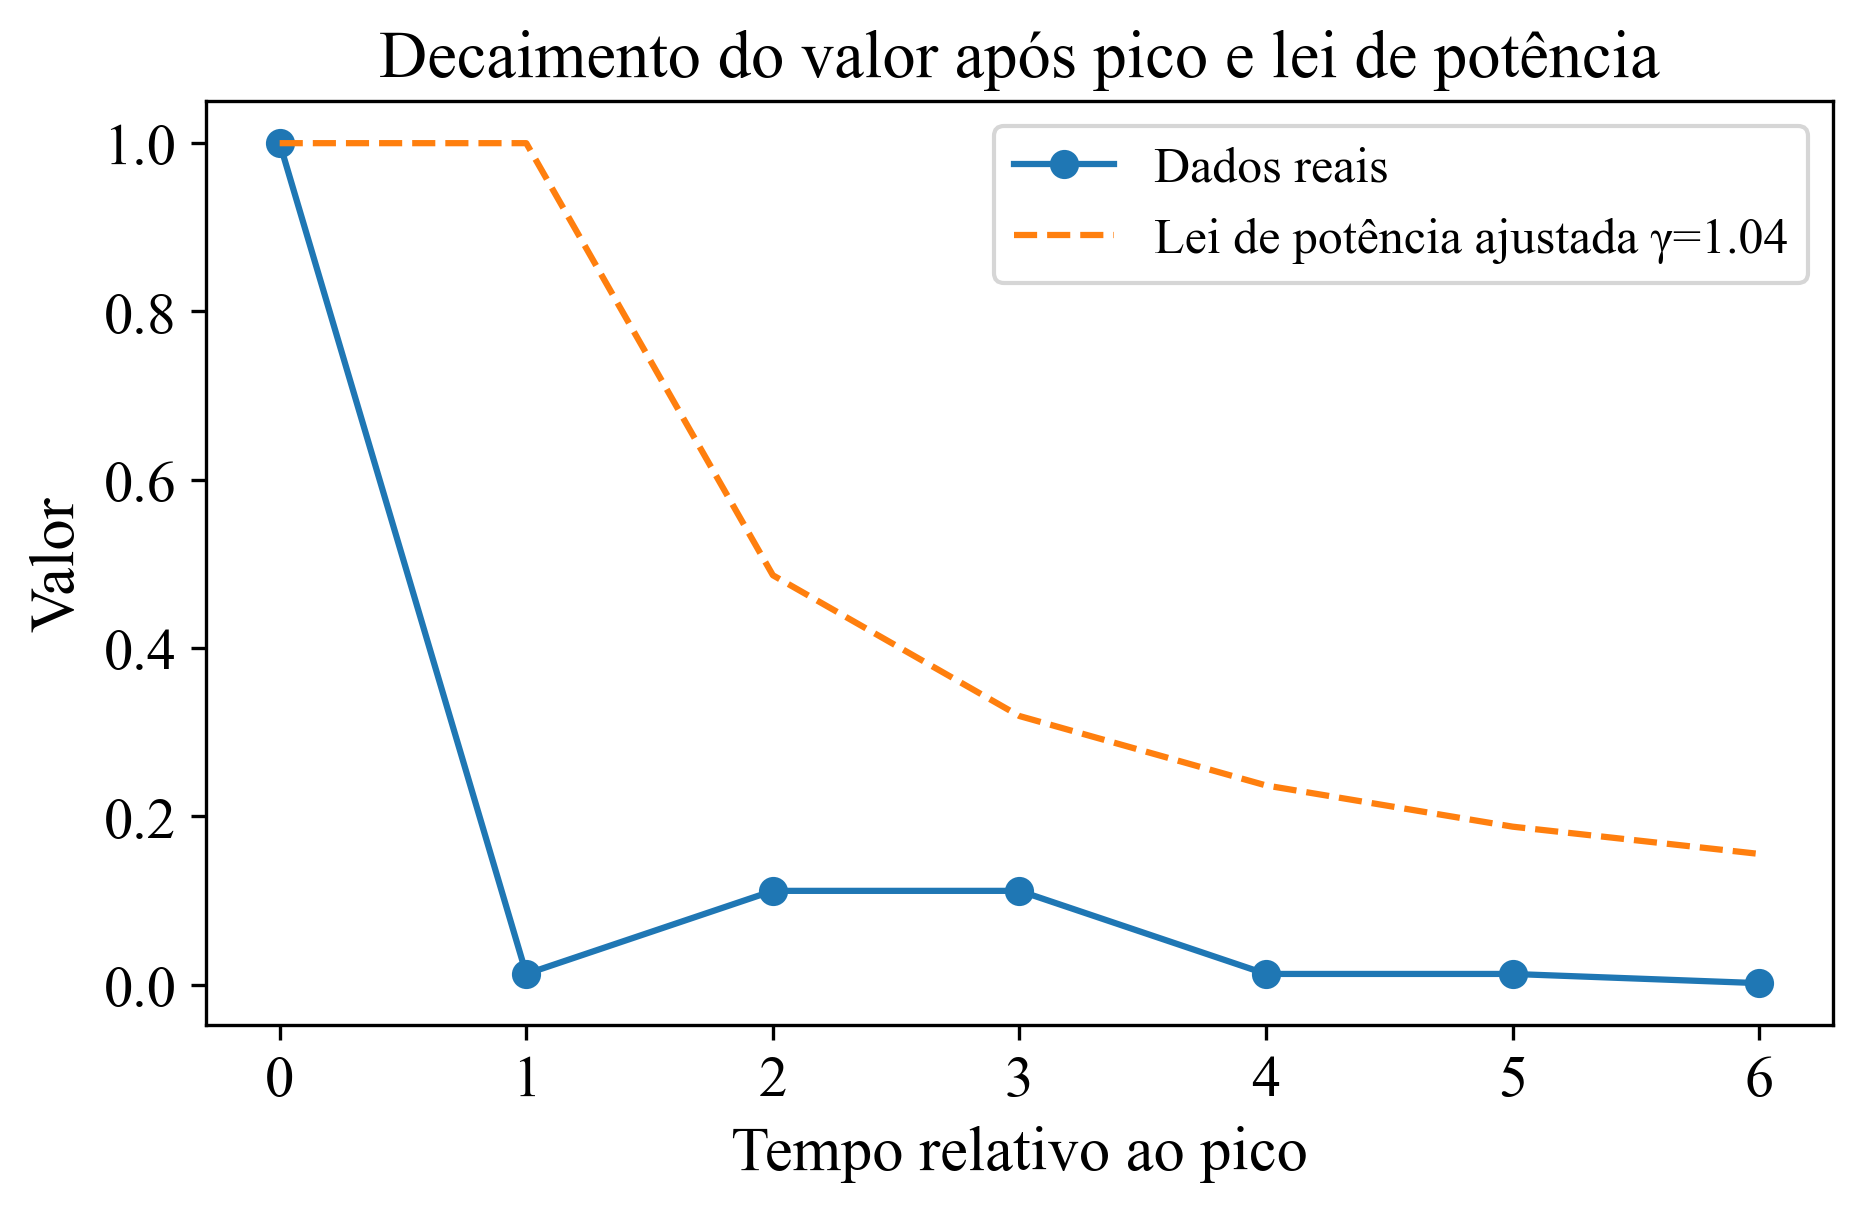

In [290]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Sua janela 'after'
y = np.array(after)
t = np.arange(len(y))  # tempo relativo a idx_max

# Para estimar γ: usamos a transformação log-log do decaimento
# Ignorando o primeiro ponto (máximo), que é t=0
y_positive = y[1:]  # evita log(0)
t_positive = t[1:]

log_t = np.log(t_positive)
log_y = np.log(y_positive)

slope, intercept, r_value, _, _ = linregress(log_t, log_y)
gamma = -slope  # expoente da lei de potência

# Curva ajustada
y_fit = y[0] * (t_positive / t_positive[0])**(-gamma)
y_fit = np.insert(y_fit, 0, y[0])  # incluir o ponto máximo no início

# Plot
plt.figure(figsize=(7,4))
plt.plot(t, y, 'o-', label='Dados reais')
plt.plot(t, y_fit, '--', label=f'Lei de potência ajustada γ={gamma:.2f}')
plt.xlabel('Tempo relativo ao pico')
plt.ylabel('Valor')
plt.title('Decaimento do valor após pico e lei de potência')
plt.legend()
plt.show()
